In [ ]:
import os
import glob
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random
import csv
from tensorflow.keras.preprocessing.image import ImageDataGenerator
!pip install -q kaggle

#!pip install -U numpy scikit-image
import numpy as np
from skimage.feature import graycomatrix, graycoprops

# Para el punto 3

import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC

In [ ]:
from google.colab import drive
import glob
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/lungcropped"
train_normal = glob.glob(os.path.join(DATASET_PATH, "train/NORMAL/*.jpeg"))
train_pneu   = glob.glob(os.path.join(DATASET_PATH, "train/PNEUMONIA/*.jpeg"))

test_normal = glob.glob(os.path.join(DATASET_PATH, "test/NORMAL/*.jpeg"))
test_pneu   = glob.glob(os.path.join(DATASET_PATH, "test/PNEUMONIA/*.jpeg"))

val_normal = glob.glob(os.path.join(DATASET_PATH, "val/NORMAL/*.jpeg"))
val_pneu   = glob.glob(os.path.join(DATASET_PATH, "val/PNEUMONIA/*.jpeg"))

print("NORMAL train:", len(train_normal))
print("PNEUMONIA train:", len(train_pneu))

print("NORMAL test:", len(test_normal))
print("PNEUMONIA test:", len(test_pneu))

print("NORMAL val:", len(val_normal))
print("PNEUMONIA val:", len(val_pneu))

Mounted at /content/drive
NORMAL train: 1341
PNEUMONIA train: 3875
NORMAL test: 234
PNEUMONIA test: 390
NORMAL val: 8
PNEUMONIA val: 8


In [ ]:
# Obtenemos los npz

# GLCM
path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_normal_test.npz"
glcm_normal_test = np.load(path)
path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_normal_train.npz"
glcm_normal_train = np.load(path)
path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_normal_val.npz"
glcm_normal_val = np.load(path)
path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_pneu_test.npz"
glcm_pneu_test = np.load(path)
path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_pneu_train.npz"
glcm_pneu_train = np.load(path)
path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_pneu_val.npz"
glcm_pneu_val = np.load(path)

# Fourier

path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/fourier_test.npz"
fourier_test = np.load(path)
path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/fourier_train.npz"
fourier_train = np.load(path)
path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/fourier_val.npz"
fourier_val = np.load(path)

def check_npz(name, npz_obj):
    print(f"\n--- Checking {name} ---")

    # Check keys
    print("Keys:", list(npz_obj.keys()))

    # Check each array stored in the NPZ
    for key in npz_obj.files:
        arr = npz_obj[key]
        print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}, empty={arr.size == 0}")

check_npz("glcm_normal_test", glcm_normal_test)
check_npz("glcm_normal_train", glcm_normal_train)
check_npz("glcm_normal_val", glcm_normal_val)

check_npz("glcm_pneu_test", glcm_pneu_test)
check_npz("glcm_pneu_train", glcm_pneu_train)
check_npz("glcm_pneu_val", glcm_pneu_val)

check_npz("fourier_test", fourier_test)
check_npz("fourier_train", fourier_train)
check_npz("fourier_val", fourier_val)



--- Checking glcm_normal_test ---
Keys: ['features', 'labels', 'filenames']
  features: shape=(234, 48), dtype=float32, empty=False
  labels: shape=(234,), dtype=<U6, empty=False
  filenames: shape=(234,), dtype=<U30, empty=False

--- Checking glcm_normal_train ---
Keys: ['features', 'labels', 'filenames']
  features: shape=(1341, 48), dtype=float32, empty=False
  labels: shape=(1341,), dtype=<U6, empty=False
  filenames: shape=(1341,), dtype=<U30, empty=False

--- Checking glcm_normal_val ---
Keys: ['features', 'labels', 'filenames']
  features: shape=(8, 48), dtype=float32, empty=False
  labels: shape=(8,), dtype=<U6, empty=False
  filenames: shape=(8,), dtype=<U25, empty=False

--- Checking glcm_pneu_test ---
Keys: ['features', 'labels', 'filenames']
  features: shape=(390, 48), dtype=float32, empty=False
  labels: shape=(390,), dtype=<U9, empty=False
  filenames: shape=(390,), dtype=<U27, empty=False

--- Checking glcm_pneu_train ---
Keys: ['features', 'labels', 'filenames']
  fea

In [ ]:
# Combinamos glmc en un solo archivo

#['X', 'y', 'files']

def merge_npz(normal, pneu, output_Path):
  X_normal = normal['features']
  files_normal = normal['filenames']

  X_pneu = pneu['features']
  files_pneu = pneu['filenames']

  # Numerical labels
  y_normal = np.zeros(len(X_normal))   # 0 = NORMAL
  y_pneu = np.ones(len(X_pneu))        # 1 = PNEUMONIA

  # Merge everything
  X = np.concatenate([X_normal, X_pneu], axis=0)
  y = np.concatenate([y_normal, y_pneu], axis=0)
  files = np.concatenate([files_normal, files_pneu], axis=0)

  # Save into one merged .npz
  np.savez(output_Path, X=X, y=y, files=files)
  print("Merged file saved as:", output_Path)



#merge_npz(glcm_normal_test, glcm_pneu_test, "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_merged_test.npz")
#merge_npz(glcm_normal_train, glcm_pneu_train, "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_merged_train.npz")
#merge_npz(glcm_normal_val, glcm_pneu_val, "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_merged_val.npz")

In [ ]:
path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_merged_val.npz"
glcm_merged_val = np.load(path)
path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_merged_train.npz"
glcm_merged_train = np.load(path)
path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_merged_test.npz"
glcm_merged_test = np.load(path)

check_npz("glcm_merged_val", glcm_merged_val)
check_npz("glcm_merged_train", glcm_merged_train)
check_npz("glcm_merged_test", glcm_merged_test)

contour_train = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_train.npz")
contour_val = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_val.npz")
contour_test = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_test.npz")

lbp_train = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_train.npz")
lbp_test = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_test.npz")
lbp_val = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_val.npz")

check_npz("contour_train", contour_train)
check_npz("contour_val", contour_val)
check_npz("contour_test", contour_test)

check_npz("lbp_train", lbp_train)
check_npz("lbp_test", lbp_test)
check_npz("lbp_val", lbp_val)


--- Checking glcm_merged_val ---
Keys: ['X', 'y', 'files']
  X: shape=(16, 48), dtype=float32, empty=False
  y: shape=(16,), dtype=float64, empty=False
  files: shape=(16,), dtype=<U29, empty=False

--- Checking glcm_merged_train ---
Keys: ['X', 'y', 'files']
  X: shape=(5216, 48), dtype=float32, empty=False
  y: shape=(5216,), dtype=float64, empty=False
  files: shape=(5216,), dtype=<U30, empty=False

--- Checking glcm_merged_test ---
Keys: ['X', 'y', 'files']
  X: shape=(624, 48), dtype=float32, empty=False
  y: shape=(624,), dtype=float64, empty=False
  files: shape=(624,), dtype=<U30, empty=False

--- Checking contour_train ---
Keys: ['X', 'y', 'files']
  X: shape=(5216, 4), dtype=float64, empty=False
  y: shape=(5216,), dtype=int64, empty=False
  files: shape=(5216,), dtype=<U164, empty=False

--- Checking contour_val ---
Keys: ['X', 'y', 'files']
  X: shape=(16, 4), dtype=float64, empty=False
  y: shape=(16,), dtype=int64, empty=False
  files: shape=(16,), dtype=<U162, empty=Fal

# Entrenamos Modelo SVC con RBF

Característica: transforma los datos en un espacio de mayor dimensión para separar clases no linealmente separables.

Cuándo usar: general-purpose, funciona bien en la mayoría de problemas.

Ventaja: flexible y potente; requiere ajustar 𝛾 y 𝐶 para un buen rendimiento.

In [ ]:
def run_pipeline_npz(form_npz, texture_npz, name="", use_pca=True, kernel='rbf'):

    print(f"DATOS RECIBIDOS (NPZ) de {name}")

    # Extraer datos
    X_form = form_npz['X']
    X_texture = texture_npz['X']
    y = texture_npz['y']

    print("Tamaños originales")
    print("Descriptor de Forma X:", X_form.shape)
    print("Descriptor de Textura X:", X_texture.shape)
    print("Etiquetas y:", y.shape)

    # Unir features
    X = np.concatenate([X_form, X_texture], axis=1)

    # Normalización
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA opcional
    if use_pca:
        pca = PCA(n_components=0.95)
        X_final = pca.fit_transform(X_scaled)
        print("\nPCA aplicado (95% varianza). Nueva forma:", X_final.shape)
    else:
        X_final = X_scaled
        print("\nPCA desactivado. Manteniendo dimensión original:", X_scaled.shape)

    # Clasificador
    clf = SVC(kernel=kernel, probability=True)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print("  VALIDACIÓN CRUZADA SVM  ")

    y_pred = cross_val_predict(clf, X_final, y, cv=cv)
    y_scores = cross_val_predict(clf, X_final, y, cv=cv, method='predict_proba')[:, 1]

    # Métricas
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    print("MÉTRICAS")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    print("Classification Report")
    print(classification_report(y, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y, y_pred)
    print("MATRIZ DE CONFUSIÓN")
    print(cm)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # Curva ROC
    fpr, tpr, thresholds = roc_curve(y, y_scores)
    roc_auc = auc(fpr, tpr)

    print(f"AUC: {roc_auc:.4f}")

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curva ROC")
    plt.legend()
    plt.grid()
    plt.show()

    return {
        "X_combined": X,
        "X_final": X_final,
        "y_pred": y_pred,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm
    }





DATOS RECIBIDOS (NPZ) de TEST
Tamaños originales
Descriptor de Forma X: (624, 20)
Descriptor de Textura X: (624, 48)
Etiquetas y: (624,)

PCA aplicado (95% varianza). Nueva forma: (624, 8)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8478
Precision : 0.8624
Recall    : 0.9000
F1-Score  : 0.8808
Classification Report
              precision    recall  f1-score   support

         0.0       0.82      0.76      0.79       234
         1.0       0.86      0.90      0.88       390

    accuracy                           0.85       624
   macro avg       0.84      0.83      0.84       624
weighted avg       0.85      0.85      0.85       624

MATRIZ DE CONFUSIÓN
[[178  56]
 [ 39 351]]


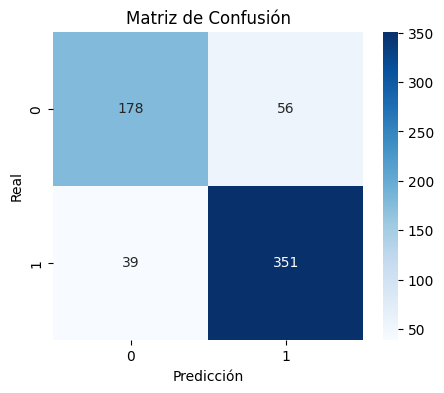

AUC: 0.9064


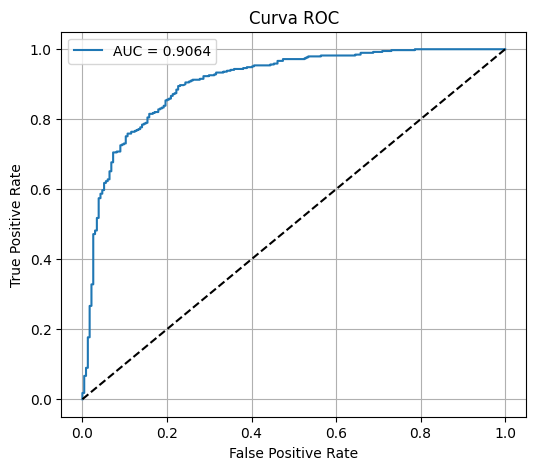

In [ ]:
result_test = run_pipeline_npz(fourier_test, glcm_merged_test, "TEST", use_pca=True, kernel='rbf')

DATOS RECIBIDOS (NPZ) de TRAIN
Tamaños originales
Descriptor de Forma X: (5216, 20)
Descriptor de Textura X: (5216, 48)
Etiquetas y: (5216,)

PCA aplicado (95% varianza). Nueva forma: (5216, 11)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.9158
Precision : 0.9392
Recall    : 0.9481
F1-Score  : 0.9436
Classification Report
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.83      1341
         1.0       0.94      0.95      0.94      3875

    accuracy                           0.92      5216
   macro avg       0.89      0.89      0.89      5216
weighted avg       0.92      0.92      0.92      5216

MATRIZ DE CONFUSIÓN
[[1103  238]
 [ 201 3674]]


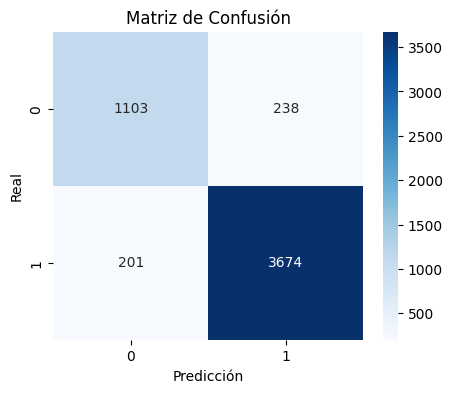

AUC: 0.9696


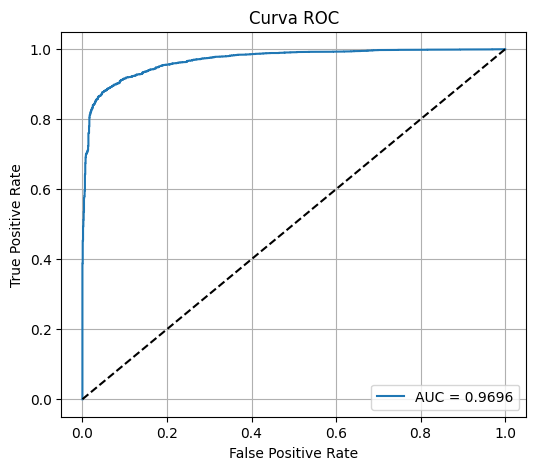

In [ ]:
result_train = run_pipeline_npz(fourier_train, glcm_merged_train, "TRAIN", use_pca=True, kernel='rbf')

DATOS RECIBIDOS (NPZ) de VAL
Tamaños originales
Descriptor de Forma X: (16, 20)
Descriptor de Textura X: (16, 48)
Etiquetas y: (16,)

PCA aplicado (95% varianza). Nueva forma: (16, 8)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.7500
Precision : 0.7000
Recall    : 0.8750
F1-Score  : 0.7778
Classification Report
              precision    recall  f1-score   support

         0.0       0.83      0.62      0.71         8
         1.0       0.70      0.88      0.78         8

    accuracy                           0.75        16
   macro avg       0.77      0.75      0.75        16
weighted avg       0.77      0.75      0.75        16

MATRIZ DE CONFUSIÓN
[[5 3]
 [1 7]]


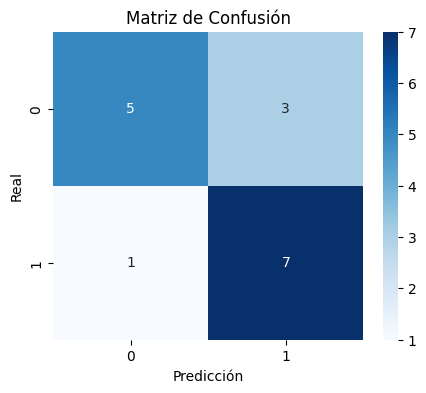

AUC: 0.1719


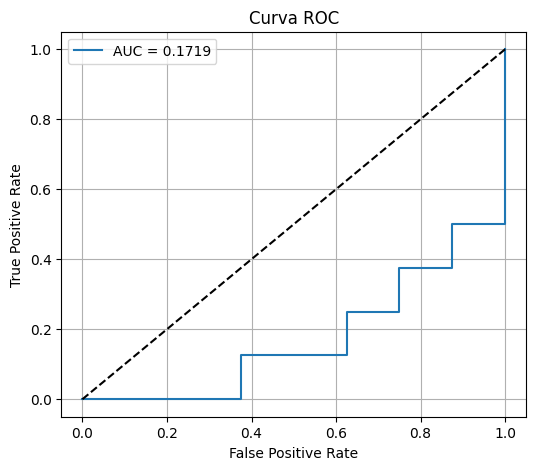

In [ ]:
result_val = run_pipeline_npz(fourier_val, glcm_merged_val, "VAL", use_pca=True, kernel='rbf')

# Evaluamos Clasificadores HU + Filtros de Gabor

In [ ]:
#Cargar Hu

hu_train = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hu_train.npz")
hu_test= np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hu_test.npz")
hu_val= np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hu_val.npz")


#Cargar Gabor

gabor_train = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/gabor_train.npz")
gabor_test= np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/gabor_test.npz")
gabor_val= np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/gabor_val.npz")

DATOS RECIBIDOS (NPZ) de TRAIN
Tamaños originales
Descriptor de Forma X: (5216, 7)
Descriptor de Textura X: (5216, 24)
Etiquetas y: (5216,)

PCA aplicado (95% varianza). Nueva forma: (5216, 10)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.9327
Precision : 0.9562
Recall    : 0.9530
F1-Score  : 0.9546
Classification Report
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1341
           1       0.96      0.95      0.95      3875

    accuracy                           0.93      5216
   macro avg       0.91      0.91      0.91      5216
weighted avg       0.93      0.93      0.93      5216

MATRIZ DE CONFUSIÓN
[[1172  169]
 [ 182 3693]]


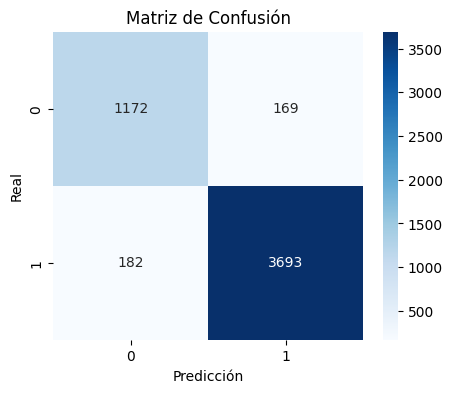

AUC: 0.9771


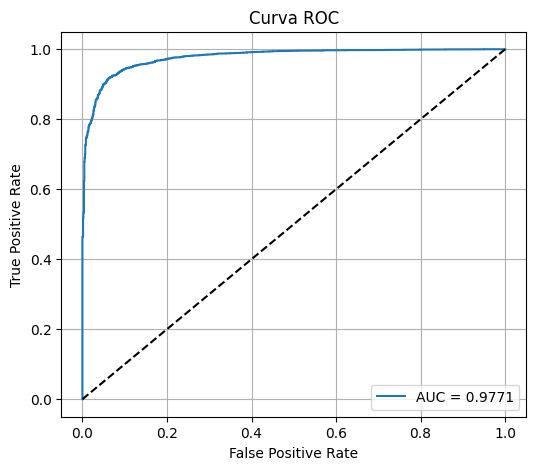

In [ ]:
results_hu_gabor_train = run_pipeline_npz(hu_train, gabor_train, "TRAIN", use_pca=True, kernel='rbf')

DATOS RECIBIDOS (NPZ) de TEST
Tamaños originales
Descriptor de Forma X: (624, 7)
Descriptor de Textura X: (624, 24)
Etiquetas y: (624,)

PCA aplicado (95% varianza). Nueva forma: (624, 10)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8381
Precision : 0.8568
Recall    : 0.8897
F1-Score  : 0.8730
Classification Report
              precision    recall  f1-score   support

           0       0.80      0.75      0.78       234
           1       0.86      0.89      0.87       390

    accuracy                           0.84       624
   macro avg       0.83      0.82      0.82       624
weighted avg       0.84      0.84      0.84       624

MATRIZ DE CONFUSIÓN
[[176  58]
 [ 43 347]]


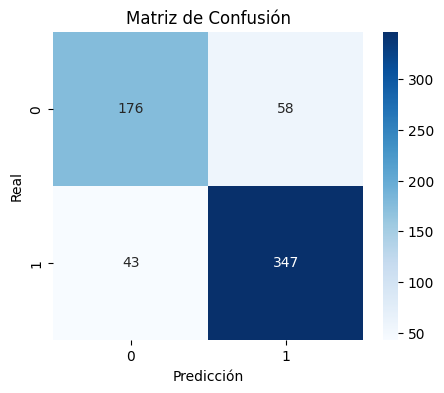

AUC: 0.9210


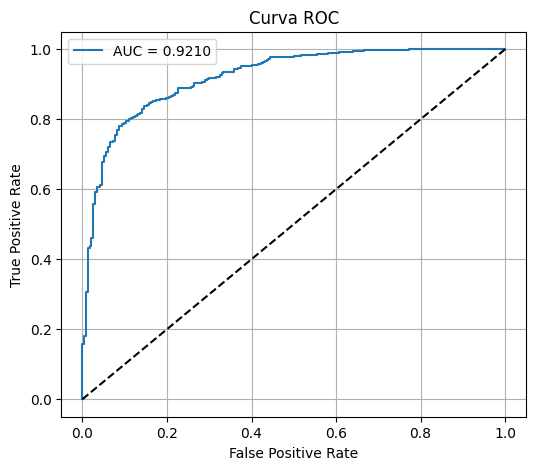

In [ ]:
results_hu_gabor_test = run_pipeline_npz(hu_test, gabor_test, "TEST", use_pca=True, kernel='rbf')

DATOS RECIBIDOS (NPZ) de VAL
Tamaños originales
Descriptor de Forma X: (16, 7)
Descriptor de Textura X: (16, 24)
Etiquetas y: (16,)

PCA aplicado (95% varianza). Nueva forma: (16, 6)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8125
Precision : 0.7778
Recall    : 0.8750
F1-Score  : 0.8235
Classification Report
              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.78      0.88      0.82         8

    accuracy                           0.81        16
   macro avg       0.82      0.81      0.81        16
weighted avg       0.82      0.81      0.81        16

MATRIZ DE CONFUSIÓN
[[6 2]
 [1 7]]


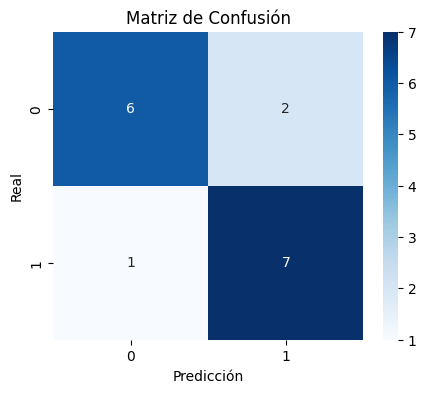

AUC: 0.9062


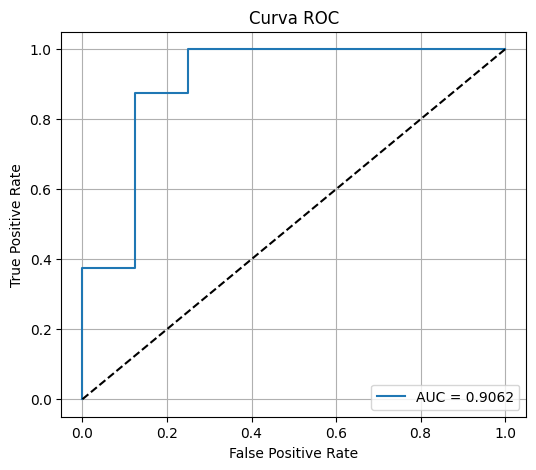

In [ ]:
results_hu_gabor_val = run_pipeline_npz(hu_val, gabor_val, "VAL", use_pca=True, kernel='rbf')

# Evaluamos Contour con lbp

DATOS RECIBIDOS (NPZ) de TRAIN
Tamaños originales
Descriptor de Forma X: (5216, 4)
Descriptor de Textura X: (5216, 54)
Etiquetas y: (5216,)

PCA aplicado (95% varianza). Nueva forma: (5216, 7)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8758
Precision : 0.9005
Recall    : 0.9363
F1-Score  : 0.9180
Classification Report
              precision    recall  f1-score   support

         0.0       0.79      0.70      0.74      1341
         1.0       0.90      0.94      0.92      3875

    accuracy                           0.88      5216
   macro avg       0.85      0.82      0.83      5216
weighted avg       0.87      0.88      0.87      5216

MATRIZ DE CONFUSIÓN
[[ 940  401]
 [ 247 3628]]


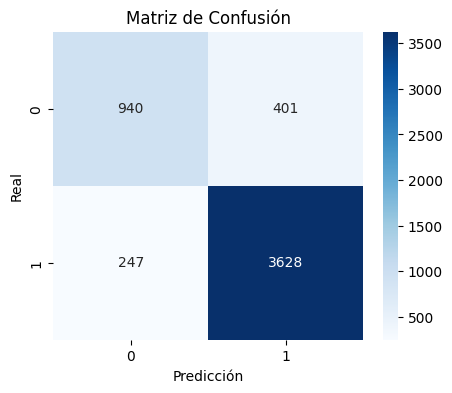

AUC: 0.9295


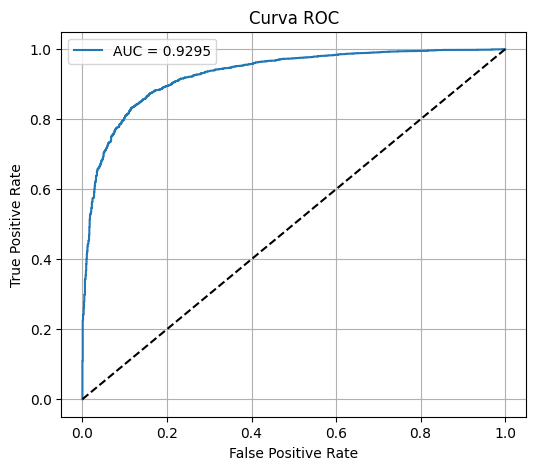

In [ ]:
results_lbp_contour_train = run_pipeline_npz(contour_train, lbp_train, "TRAIN", use_pca=True, kernel='rbf')

DATOS RECIBIDOS (NPZ) de TEST
Tamaños originales
Descriptor de Forma X: (624, 4)
Descriptor de Textura X: (624, 54)
Etiquetas y: (624,)

PCA aplicado (95% varianza). Nueva forma: (624, 7)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.7580
Precision : 0.7581
Recall    : 0.9000
F1-Score  : 0.8230
Classification Report
              precision    recall  f1-score   support

         0.0       0.76      0.52      0.62       234
         1.0       0.76      0.90      0.82       390

    accuracy                           0.76       624
   macro avg       0.76      0.71      0.72       624
weighted avg       0.76      0.76      0.75       624

MATRIZ DE CONFUSIÓN
[[122 112]
 [ 39 351]]


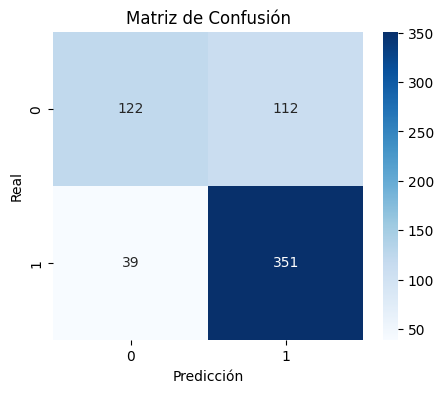

AUC: 0.8080


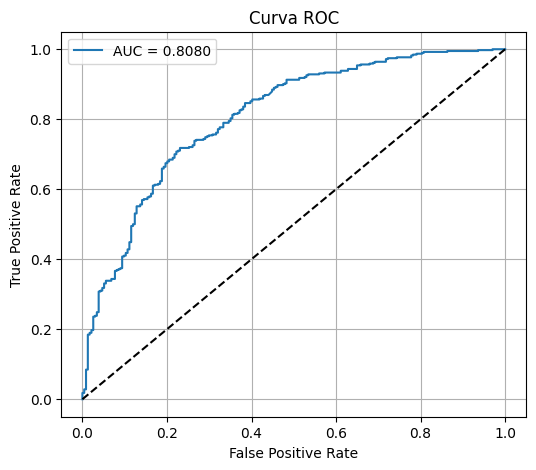

In [ ]:
results_lbp_contour_test = run_pipeline_npz(contour_test, lbp_test, "TEST", use_pca=True, kernel='rbf')

DATOS RECIBIDOS (NPZ) de Val
Tamaños originales
Descriptor de Forma X: (16, 4)
Descriptor de Textura X: (16, 54)
Etiquetas y: (16,)

PCA aplicado (95% varianza). Nueva forma: (16, 5)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.7500
Precision : 0.8333
Recall    : 0.6250
F1-Score  : 0.7143
Classification Report
              precision    recall  f1-score   support

         0.0       0.70      0.88      0.78         8
         1.0       0.83      0.62      0.71         8

    accuracy                           0.75        16
   macro avg       0.77      0.75      0.75        16
weighted avg       0.77      0.75      0.75        16

MATRIZ DE CONFUSIÓN
[[7 1]
 [3 5]]


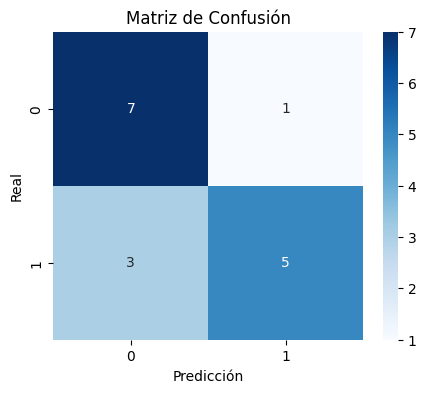

AUC: 0.1875


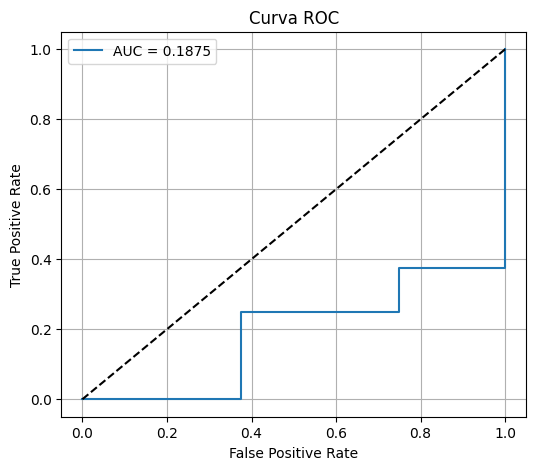

In [ ]:
results_lbp_contour_val = run_pipeline_npz(contour_val, lbp_val, "Val", use_pca=True, kernel='rbf')

# Probamos con el Kernel linear

Característica: separa los datos con un hiperplano lineal.

Cuándo usar: cuando los datos son aproximadamente linealmente separables.

Ventaja: rápido y simple, menos riesgo de sobreajuste.

## Fourier + GLMC

DATOS RECIBIDOS (NPZ) de TEST SVC Linear
Tamaños originales
Descriptor de Forma X: (624, 20)
Descriptor de Textura X: (624, 48)
Etiquetas y: (624,)

PCA aplicado (95% varianza). Nueva forma: (624, 8)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8301
Precision : 0.8550
Recall    : 0.8769
F1-Score  : 0.8658
Classification Report
              precision    recall  f1-score   support

         0.0       0.79      0.75      0.77       234
         1.0       0.85      0.88      0.87       390

    accuracy                           0.83       624
   macro avg       0.82      0.81      0.82       624
weighted avg       0.83      0.83      0.83       624

MATRIZ DE CONFUSIÓN
[[176  58]
 [ 48 342]]


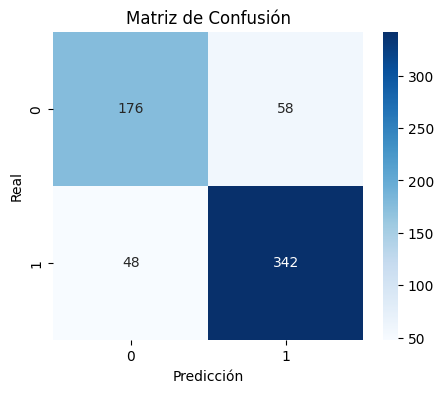

AUC: 0.8987


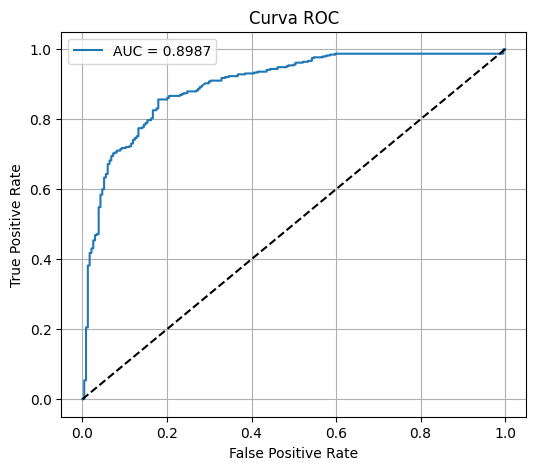

DATOS RECIBIDOS (NPZ) de TRAIN SVC Linear
Tamaños originales
Descriptor de Forma X: (5216, 20)
Descriptor de Textura X: (5216, 48)
Etiquetas y: (5216,)

PCA aplicado (95% varianza). Nueva forma: (5216, 11)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8978
Precision : 0.9285
Recall    : 0.9345
F1-Score  : 0.9314
Classification Report
              precision    recall  f1-score   support

         0.0       0.81      0.79      0.80      1341
         1.0       0.93      0.93      0.93      3875

    accuracy                           0.90      5216
   macro avg       0.87      0.86      0.87      5216
weighted avg       0.90      0.90      0.90      5216

MATRIZ DE CONFUSIÓN
[[1062  279]
 [ 254 3621]]


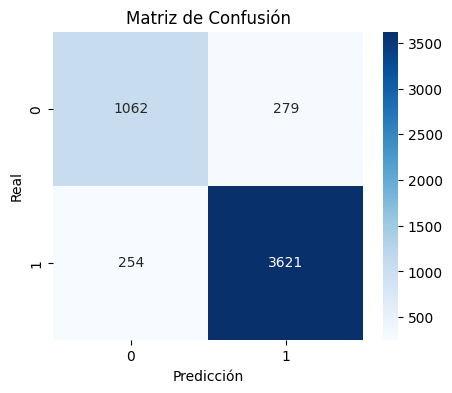

AUC: 0.9543


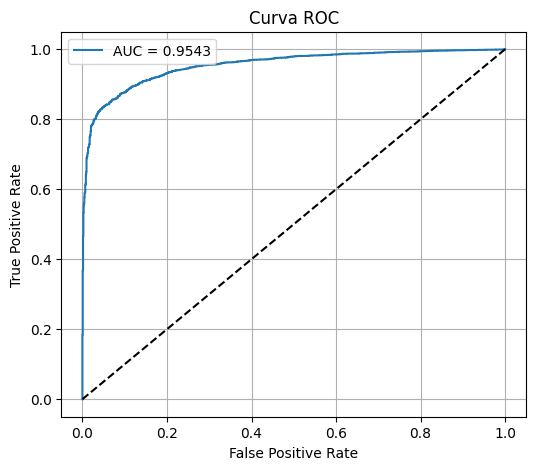

DATOS RECIBIDOS (NPZ) de VAL SVC Linear
Tamaños originales
Descriptor de Forma X: (16, 20)
Descriptor de Textura X: (16, 48)
Etiquetas y: (16,)

PCA aplicado (95% varianza). Nueva forma: (16, 8)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.6875
Precision : 0.6667
Recall    : 0.7500
F1-Score  : 0.7059
Classification Report
              precision    recall  f1-score   support

         0.0       0.71      0.62      0.67         8
         1.0       0.67      0.75      0.71         8

    accuracy                           0.69        16
   macro avg       0.69      0.69      0.69        16
weighted avg       0.69      0.69      0.69        16

MATRIZ DE CONFUSIÓN
[[5 3]
 [2 6]]


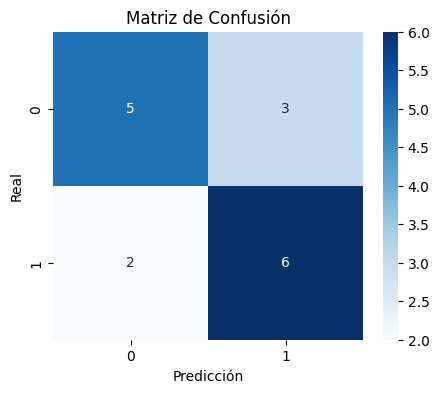

AUC: 0.6875


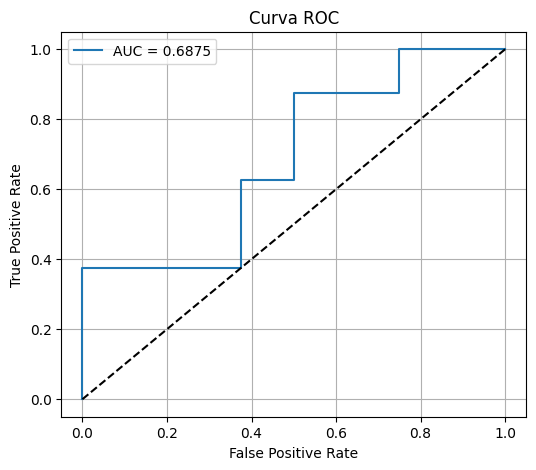

In [ ]:
results_linear_test = run_pipeline_npz(fourier_test, glcm_merged_test, name="TEST SVC Linear", kernel='linear')
results_linear_train = run_pipeline_npz(fourier_train, glcm_merged_train, name="TRAIN SVC Linear", kernel='linear')
results_linear_val = run_pipeline_npz(fourier_val, glcm_merged_val, name="VAL SVC Linear", kernel='linear')

## Hu + Gabor

DATOS RECIBIDOS (NPZ) de TRAIN Linear
Tamaños originales
Descriptor de Forma X: (5216, 7)
Descriptor de Textura X: (5216, 24)
Etiquetas y: (5216,)

PCA aplicado (95% varianza). Nueva forma: (5216, 10)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.9275
Precision : 0.9540
Recall    : 0.9481
F1-Score  : 0.9511
Classification Report
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1341
           1       0.95      0.95      0.95      3875

    accuracy                           0.93      5216
   macro avg       0.90      0.91      0.91      5216
weighted avg       0.93      0.93      0.93      5216

MATRIZ DE CONFUSIÓN
[[1164  177]
 [ 201 3674]]


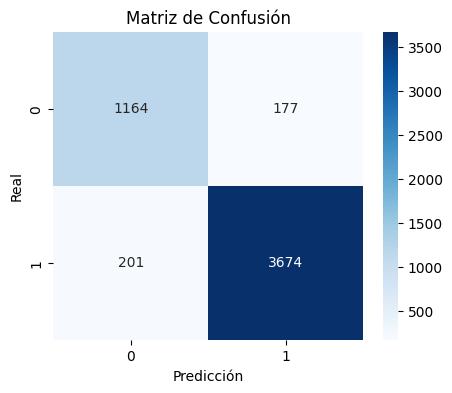

AUC: 0.9718


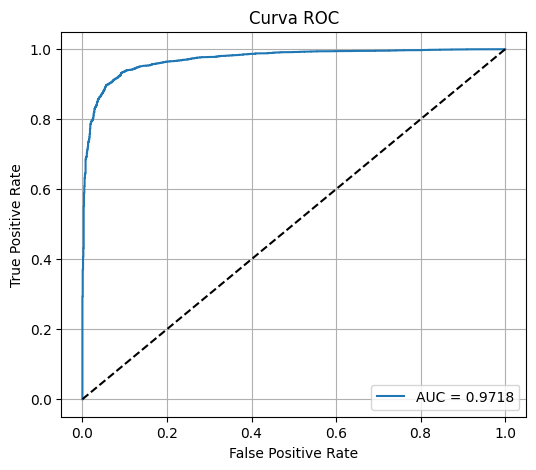

DATOS RECIBIDOS (NPZ) de TEST Linear
Tamaños originales
Descriptor de Forma X: (624, 7)
Descriptor de Textura X: (624, 24)
Etiquetas y: (624,)

PCA aplicado (95% varianza). Nueva forma: (624, 10)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8654
Precision : 0.8844
Recall    : 0.9026
F1-Score  : 0.8934
Classification Report
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       234
           1       0.88      0.90      0.89       390

    accuracy                           0.87       624
   macro avg       0.86      0.85      0.86       624
weighted avg       0.86      0.87      0.86       624

MATRIZ DE CONFUSIÓN
[[188  46]
 [ 38 352]]


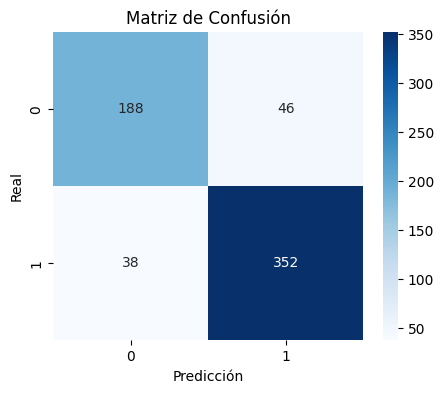

AUC: 0.9301


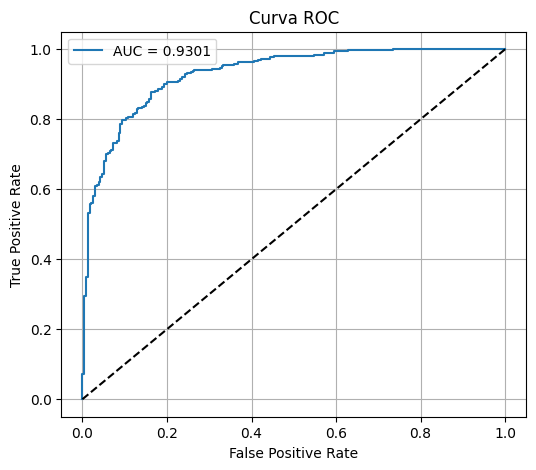

DATOS RECIBIDOS (NPZ) de VAL Linear
Tamaños originales
Descriptor de Forma X: (16, 7)
Descriptor de Textura X: (16, 24)
Etiquetas y: (16,)

PCA aplicado (95% varianza). Nueva forma: (16, 6)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8750
Precision : 1.0000
Recall    : 0.7500
F1-Score  : 0.8571
Classification Report
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       1.00      0.75      0.86         8

    accuracy                           0.88        16
   macro avg       0.90      0.88      0.87        16
weighted avg       0.90      0.88      0.87        16

MATRIZ DE CONFUSIÓN
[[8 0]
 [2 6]]


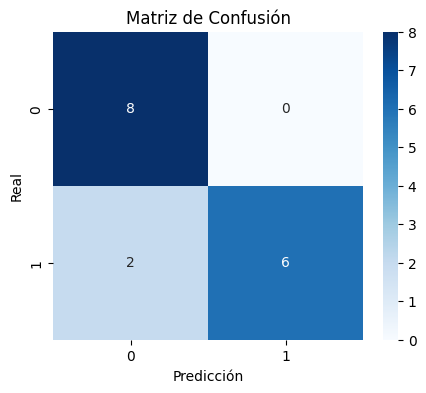

AUC: 0.9062


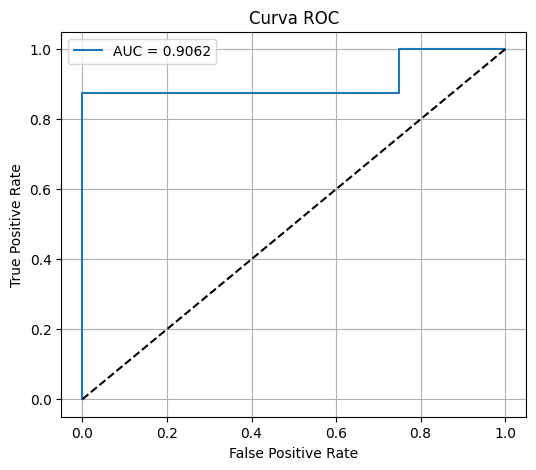

In [ ]:
results_linear_hu_gabor_train = run_pipeline_npz(hu_train, gabor_train, "TRAIN Linear", use_pca=True, kernel='linear')
results_linear_hu_gabor_test = run_pipeline_npz(hu_test, gabor_test, "TEST Linear", use_pca=True, kernel='linear')
results_linear_hu_gabor_val = run_pipeline_npz(hu_val, gabor_val, "VAL Linear", use_pca=True, kernel='linear')

# Contour + lbp en Linear

DATOS RECIBIDOS (NPZ) de TRAIN
Tamaños originales
Descriptor de Forma X: (5216, 4)
Descriptor de Textura X: (5216, 54)
Etiquetas y: (5216,)

PCA aplicado (95% varianza). Nueva forma: (5216, 7)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8434
Precision : 0.8794
Recall    : 0.9146
F1-Score  : 0.8966
Classification Report
              precision    recall  f1-score   support

         0.0       0.72      0.64      0.68      1341
         1.0       0.88      0.91      0.90      3875

    accuracy                           0.84      5216
   macro avg       0.80      0.78      0.79      5216
weighted avg       0.84      0.84      0.84      5216

MATRIZ DE CONFUSIÓN
[[ 855  486]
 [ 331 3544]]


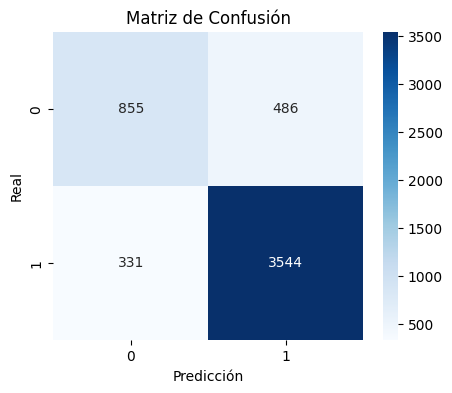

AUC: 0.9032


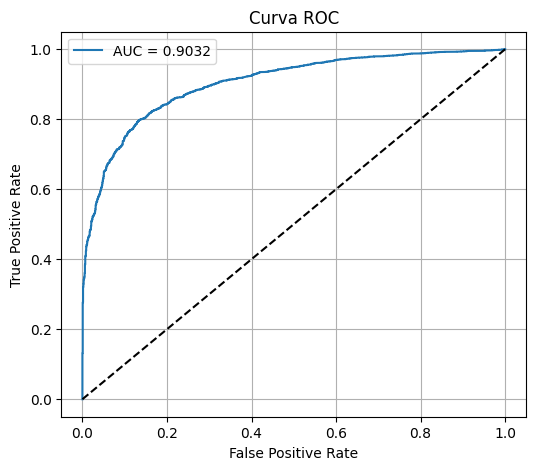

In [ ]:
results_lbp_contour_train_linear = run_pipeline_npz(contour_train, lbp_train, "TRAIN", use_pca=True, kernel='linear')

DATOS RECIBIDOS (NPZ) de TEST
Tamaños originales
Descriptor de Forma X: (624, 4)
Descriptor de Textura X: (624, 54)
Etiquetas y: (624,)

PCA aplicado (95% varianza). Nueva forma: (624, 7)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.7564
Precision : 0.7793
Recall    : 0.8513
F1-Score  : 0.8137
Classification Report
              precision    recall  f1-score   support

         0.0       0.71      0.60      0.65       234
         1.0       0.78      0.85      0.81       390

    accuracy                           0.76       624
   macro avg       0.74      0.72      0.73       624
weighted avg       0.75      0.76      0.75       624

MATRIZ DE CONFUSIÓN
[[140  94]
 [ 58 332]]


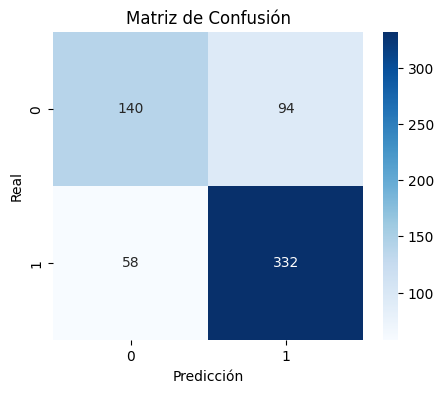

AUC: 0.8050


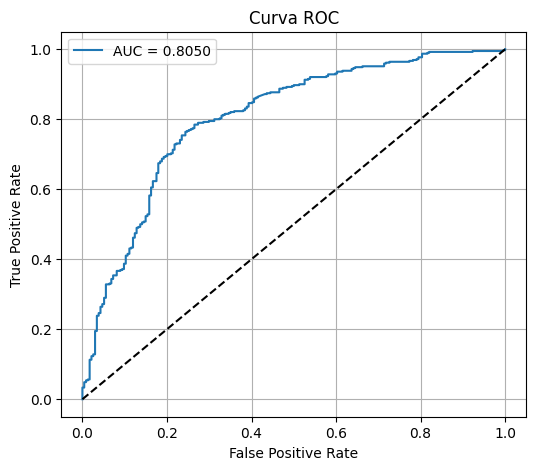

In [ ]:
results_lbp_contour_test_linear = run_pipeline_npz(contour_test, lbp_test, "TEST", use_pca=True, kernel='linear')

DATOS RECIBIDOS (NPZ) de Val
Tamaños originales
Descriptor de Forma X: (16, 4)
Descriptor de Textura X: (16, 54)
Etiquetas y: (16,)

PCA aplicado (95% varianza). Nueva forma: (16, 5)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8750
Precision : 0.8750
Recall    : 0.8750
F1-Score  : 0.8750
Classification Report
              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88         8
         1.0       0.88      0.88      0.88         8

    accuracy                           0.88        16
   macro avg       0.88      0.88      0.88        16
weighted avg       0.88      0.88      0.88        16

MATRIZ DE CONFUSIÓN
[[7 1]
 [1 7]]


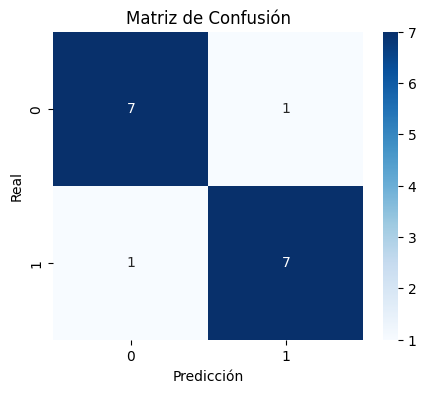

AUC: 0.5938


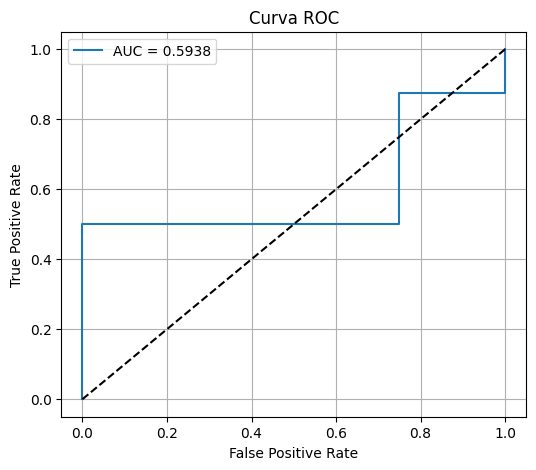

In [ ]:
results_lbp_contour_val_linear = run_pipeline_npz(contour_val, lbp_val, "Val", use_pca=True, kernel='linear')

# Probamos con el Kernel Poly

Característica: permite separar datos con fronteras no lineales usando un polinomio de grado
𝑑

Cuándo usar: cuando las relaciones entre features tienen interacciones complejas.

Ventaja: más flexible que linear, pero puede sobreajustar si el grado es alto.

## Fourier GLCM

DATOS RECIBIDOS (NPZ) de TEST SVC Poly
Tamaños originales
Descriptor de Forma X: (624, 20)
Descriptor de Textura X: (624, 48)
Etiquetas y: (624,)

PCA aplicado (95% varianza). Nueva forma: (624, 8)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.7580
Precision : 0.7348
Recall    : 0.9590
F1-Score  : 0.8320
Classification Report
              precision    recall  f1-score   support

         0.0       0.86      0.42      0.57       234
         1.0       0.73      0.96      0.83       390

    accuracy                           0.76       624
   macro avg       0.80      0.69      0.70       624
weighted avg       0.78      0.76      0.73       624

MATRIZ DE CONFUSIÓN
[[ 99 135]
 [ 16 374]]


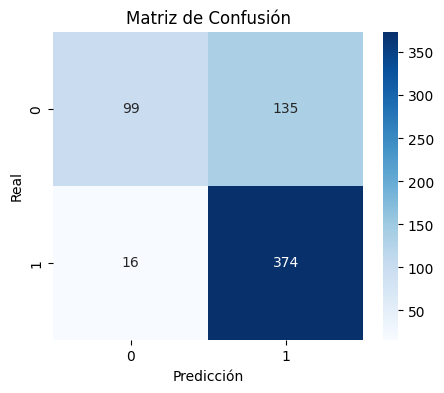

AUC: 0.8819


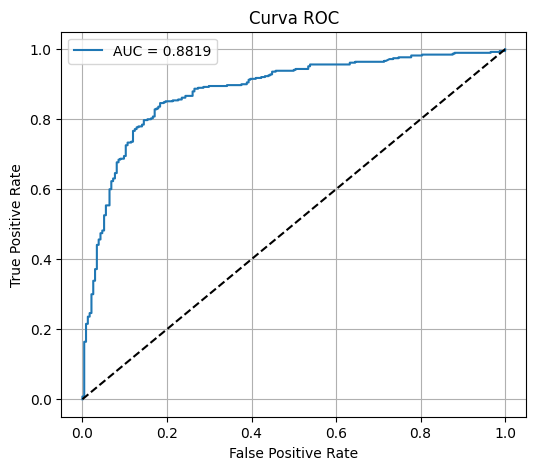

In [ ]:
results_Poly_test = run_pipeline_npz(fourier_test, glcm_merged_test, name="TEST SVC Poly", kernel='poly')

DATOS RECIBIDOS (NPZ) de TRAIN SVC Poly
Tamaños originales
Descriptor de Forma X: (5216, 20)
Descriptor de Textura X: (5216, 48)
Etiquetas y: (5216,)

PCA aplicado (95% varianza). Nueva forma: (5216, 11)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8551
Precision : 0.8532
Recall    : 0.9721
F1-Score  : 0.9088
Classification Report
              precision    recall  f1-score   support

         0.0       0.87      0.52      0.65      1341
         1.0       0.85      0.97      0.91      3875

    accuracy                           0.86      5216
   macro avg       0.86      0.74      0.78      5216
weighted avg       0.86      0.86      0.84      5216

MATRIZ DE CONFUSIÓN
[[ 693  648]
 [ 108 3767]]


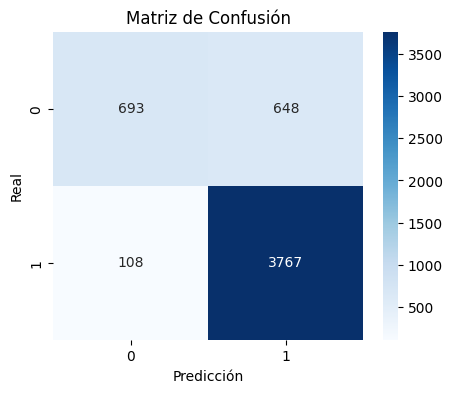

AUC: 0.9451


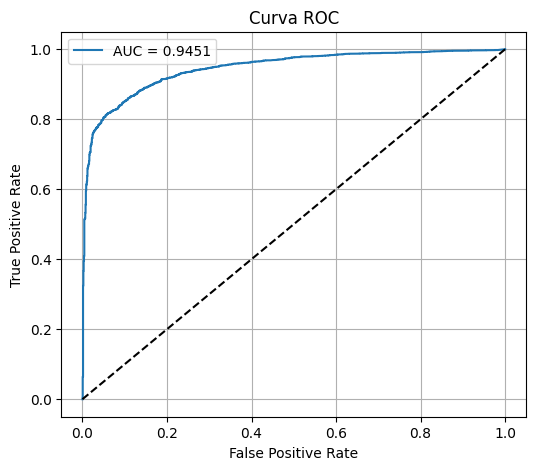

In [ ]:
results_Poly_train = run_pipeline_npz(fourier_train, glcm_merged_train, name="TRAIN SVC Poly", kernel='poly')

DATOS RECIBIDOS (NPZ) de VAL SVC Poly
Tamaños originales
Descriptor de Forma X: (16, 20)
Descriptor de Textura X: (16, 48)
Etiquetas y: (16,)

PCA aplicado (95% varianza). Nueva forma: (16, 8)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.5000
Precision : 0.5000
Recall    : 0.6250
F1-Score  : 0.5556
Classification Report
              precision    recall  f1-score   support

         0.0       0.50      0.38      0.43         8
         1.0       0.50      0.62      0.56         8

    accuracy                           0.50        16
   macro avg       0.50      0.50      0.49        16
weighted avg       0.50      0.50      0.49        16

MATRIZ DE CONFUSIÓN
[[3 5]
 [3 5]]


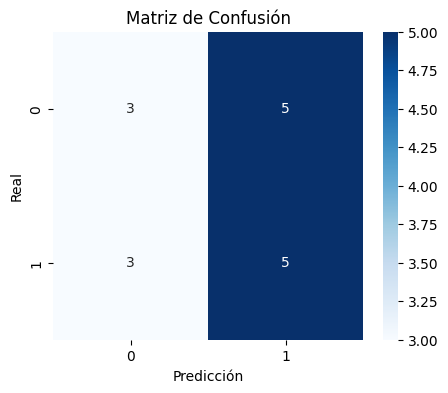

AUC: 0.3125


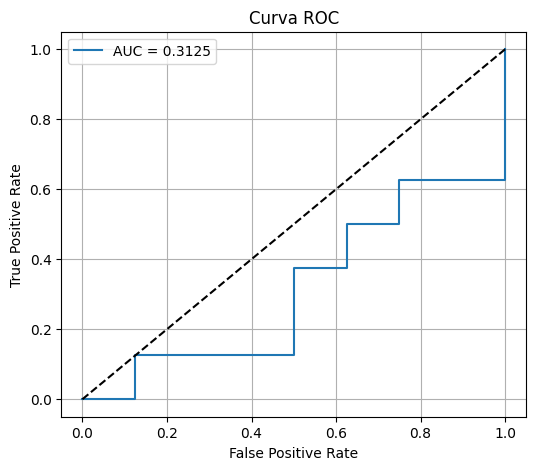

In [ ]:
results_Poly_val = run_pipeline_npz(fourier_val, glcm_merged_val, name="VAL SVC Poly", kernel='poly')

## Hu Gabor

DATOS RECIBIDOS (NPZ) de TRAIN Poly
Tamaños originales
Descriptor de Forma X: (5216, 7)
Descriptor de Textura X: (5216, 24)
Etiquetas y: (5216,)

PCA aplicado (95% varianza). Nueva forma: (5216, 10)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.8871
Precision : 0.8830
Recall    : 0.9775
F1-Score  : 0.9279
Classification Report
              precision    recall  f1-score   support

           0       0.91      0.63      0.74      1341
           1       0.88      0.98      0.93      3875

    accuracy                           0.89      5216
   macro avg       0.89      0.80      0.83      5216
weighted avg       0.89      0.89      0.88      5216

MATRIZ DE CONFUSIÓN
[[ 839  502]
 [  87 3788]]


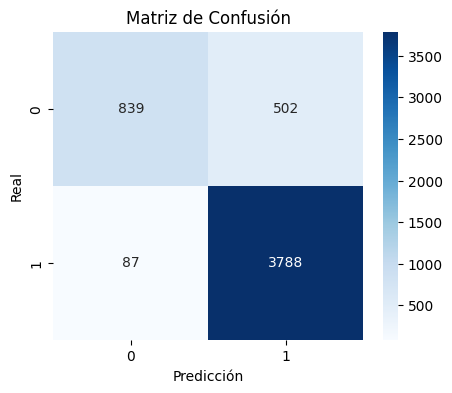

AUC: 0.9638


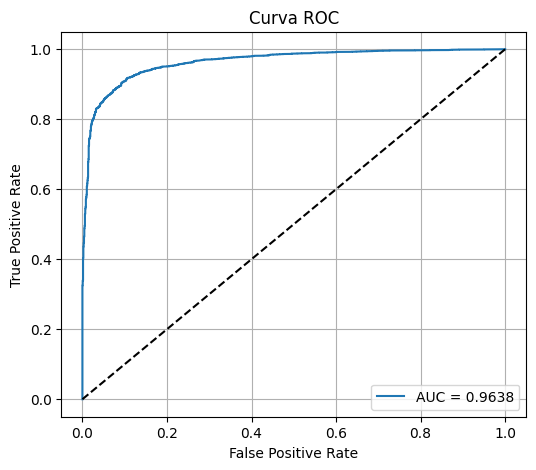

In [ ]:
results_Poly_hu_gabor_train = run_pipeline_npz(hu_train, gabor_train, "TRAIN Poly", use_pca=True, kernel='poly')

DATOS RECIBIDOS (NPZ) de TEST Poly
Tamaños originales
Descriptor de Forma X: (624, 7)
Descriptor de Textura X: (624, 24)
Etiquetas y: (624,)

PCA aplicado (95% varianza). Nueva forma: (624, 10)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.7788
Precision : 0.7636
Recall    : 0.9359
F1-Score  : 0.8410
Classification Report
              precision    recall  f1-score   support

           0       0.83      0.52      0.64       234
           1       0.76      0.94      0.84       390

    accuracy                           0.78       624
   macro avg       0.80      0.73      0.74       624
weighted avg       0.79      0.78      0.76       624

MATRIZ DE CONFUSIÓN
[[121 113]
 [ 25 365]]


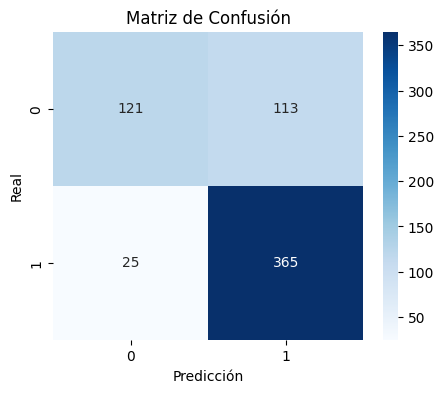

AUC: 0.8919


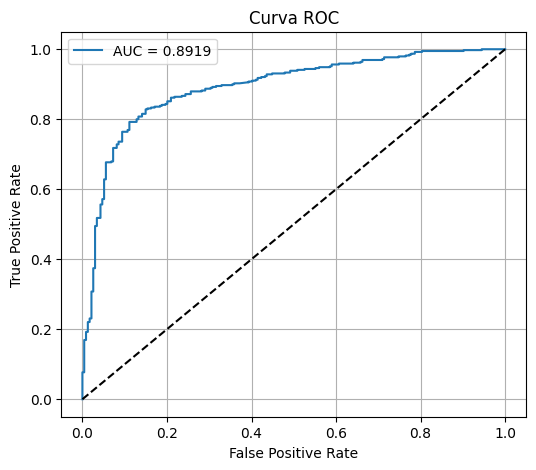

In [ ]:
results_Poly_hu_gabor_test = run_pipeline_npz(hu_test, gabor_test, "TEST Poly", use_pca=True, kernel='poly')

DATOS RECIBIDOS (NPZ) de VAL Poly
Tamaños originales
Descriptor de Forma X: (16, 7)
Descriptor de Textura X: (16, 24)
Etiquetas y: (16,)

PCA aplicado (95% varianza). Nueva forma: (16, 6)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.6250
Precision : 0.6667
Recall    : 0.5000
F1-Score  : 0.5714
Classification Report
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         8
           1       0.67      0.50      0.57         8

    accuracy                           0.62        16
   macro avg       0.63      0.62      0.62        16
weighted avg       0.63      0.62      0.62        16

MATRIZ DE CONFUSIÓN
[[6 2]
 [4 4]]


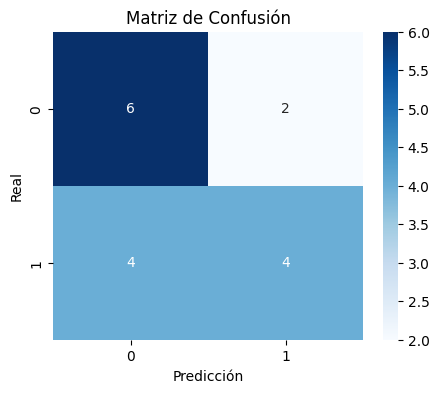

AUC: 0.4688


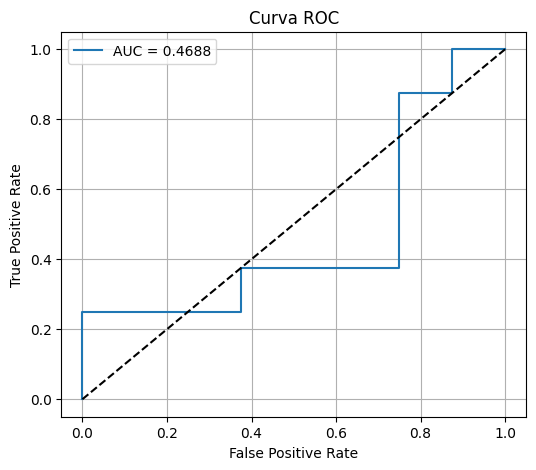

In [ ]:
results_Poly_hu_gabor_val = run_pipeline_npz(hu_val, gabor_val, "VAL Poly", use_pca=True, kernel='poly')

# Contour + Lbp en Poly

DATOS RECIBIDOS (NPZ) de TRAIN
Tamaños originales
Descriptor de Forma X: (5216, 4)
Descriptor de Textura X: (5216, 54)
Etiquetas y: (5216,)

PCA aplicado (95% varianza). Nueva forma: (5216, 7)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.7868
Precision : 0.7848
Recall    : 0.9825
F1-Score  : 0.8726
Classification Report
              precision    recall  f1-score   support

         0.0       0.81      0.22      0.35      1341
         1.0       0.78      0.98      0.87      3875

    accuracy                           0.79      5216
   macro avg       0.80      0.60      0.61      5216
weighted avg       0.79      0.79      0.74      5216

MATRIZ DE CONFUSIÓN
[[ 297 1044]
 [  68 3807]]


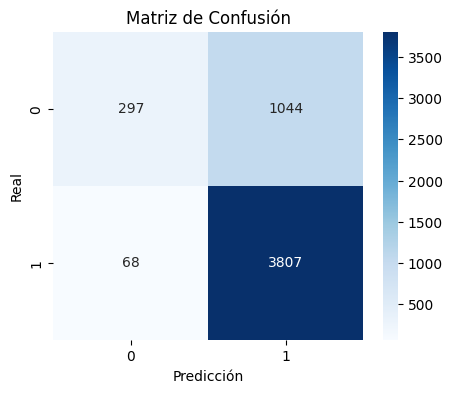

AUC: 0.8651


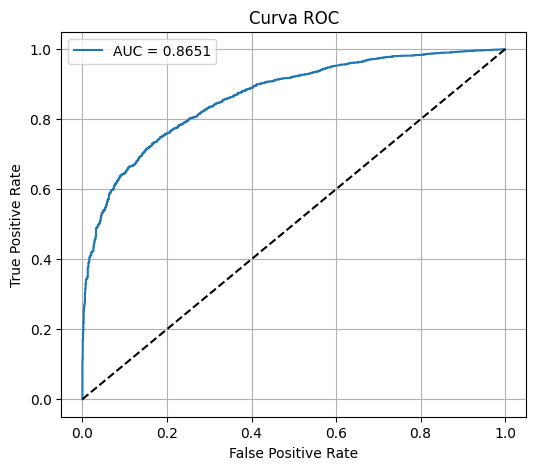

In [ ]:
results_lbp_contour_train_poly = run_pipeline_npz(contour_train, lbp_train, "TRAIN", use_pca=True, kernel='poly')

DATOS RECIBIDOS (NPZ) de TEST
Tamaños originales
Descriptor de Forma X: (624, 4)
Descriptor de Textura X: (624, 54)
Etiquetas y: (624,)

PCA aplicado (95% varianza). Nueva forma: (624, 7)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.6619
Precision : 0.6578
Recall    : 0.9564
F1-Score  : 0.7795
Classification Report
              precision    recall  f1-score   support

         0.0       0.70      0.17      0.27       234
         1.0       0.66      0.96      0.78       390

    accuracy                           0.66       624
   macro avg       0.68      0.56      0.53       624
weighted avg       0.67      0.66      0.59       624

MATRIZ DE CONFUSIÓN
[[ 40 194]
 [ 17 373]]


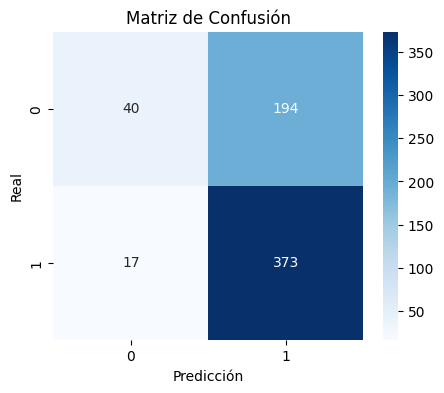

AUC: 0.7657


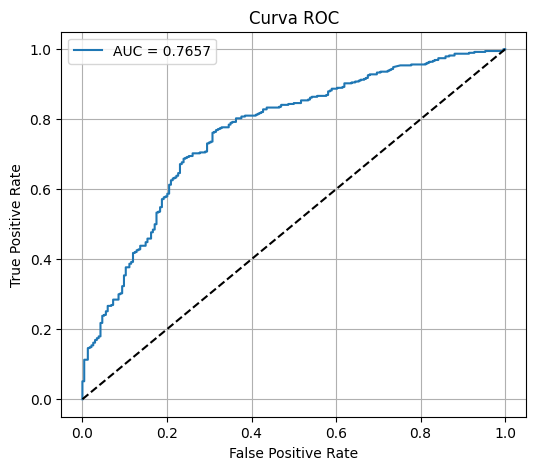

In [ ]:
results_lbp_contour_test_poly = run_pipeline_npz(contour_test, lbp_test, "TEST", use_pca=True, kernel='poly')

DATOS RECIBIDOS (NPZ) de Val
Tamaños originales
Descriptor de Forma X: (16, 4)
Descriptor de Textura X: (16, 54)
Etiquetas y: (16,)

PCA aplicado (95% varianza). Nueva forma: (16, 5)
  VALIDACIÓN CRUZADA SVM  
MÉTRICAS
Accuracy  : 0.5000
Precision : 0.5000
Recall    : 0.2500
F1-Score  : 0.3333
Classification Report
              precision    recall  f1-score   support

         0.0       0.50      0.75      0.60         8
         1.0       0.50      0.25      0.33         8

    accuracy                           0.50        16
   macro avg       0.50      0.50      0.47        16
weighted avg       0.50      0.50      0.47        16

MATRIZ DE CONFUSIÓN
[[6 2]
 [6 2]]


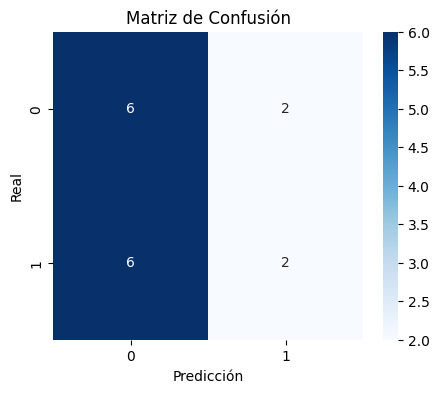

AUC: 0.4688


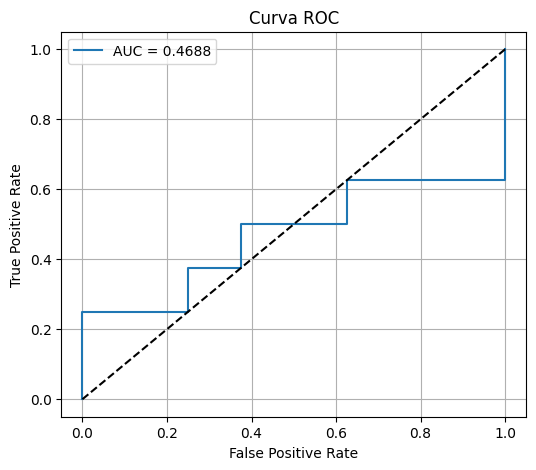

In [ ]:
results_lbp_contour_val_poly = run_pipeline_npz(contour_val, lbp_val, "Val", use_pca=True, kernel='poly')

In [ ]:
# Métricas a mostrar
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]


# Etiquetas simplificadas
labels = ["","1-FourierxGLMC", "2-HuGabor", "3-LBPContour"]

# Print compacto de cada resultado
def print_results(results_list, name=""):
    for i, res in enumerate(results_list, 1):
        metric_str = " | ".join([f"{k}: {res[k]:.4f}" for k in metrics])
        print(f"Resultado {name} {labels[i]}: {metric_str}")

# Resultados Rbf

resultList_Glmc_Fourier_Test = [result_test, results_hu_gabor_test, results_lbp_contour_test]
resultList_Glmc_Fourier_Train = [result_train, results_hu_gabor_train, results_lbp_contour_train]
resultList_Glmc_Fourier_Val = [result_val, results_hu_gabor_val, results_lbp_contour_val]

print_results(resultList_Glmc_Fourier_Test, "RBF Test")
print_results(resultList_Glmc_Fourier_Train, "RBF Train")
print_results(resultList_Glmc_Fourier_Val, "RBF Val")


Resultado RBF Test 1-FourierxGLMC: accuracy: 0.8478 | precision: 0.8624 | recall: 0.9000 | f1: 0.8808 | roc_auc: 0.9064
Resultado RBF Test 2-HuGabor: accuracy: 0.8381 | precision: 0.8568 | recall: 0.8897 | f1: 0.8730 | roc_auc: 0.9210
Resultado RBF Test 3-LBPContour: accuracy: 0.7580 | precision: 0.7581 | recall: 0.9000 | f1: 0.8230 | roc_auc: 0.8080
Resultado RBF Train 1-FourierxGLMC: accuracy: 0.9158 | precision: 0.9392 | recall: 0.9481 | f1: 0.9436 | roc_auc: 0.9696
Resultado RBF Train 2-HuGabor: accuracy: 0.9327 | precision: 0.9562 | recall: 0.9530 | f1: 0.9546 | roc_auc: 0.9771
Resultado RBF Train 3-LBPContour: accuracy: 0.8758 | precision: 0.9005 | recall: 0.9363 | f1: 0.9180 | roc_auc: 0.9295
Resultado RBF Val 1-FourierxGLMC: accuracy: 0.7500 | precision: 0.7000 | recall: 0.8750 | f1: 0.7778 | roc_auc: 0.1719
Resultado RBF Val 2-HuGabor: accuracy: 0.8125 | precision: 0.7778 | recall: 0.8750 | f1: 0.8235 | roc_auc: 0.9062
Resultado RBF Val 3-LBPContour: accuracy: 0.7500 | precisi

In [ ]:
# Resultados Linear

resultsList_Linear_Test = [results_linear_test, results_linear_hu_gabor_test, results_lbp_contour_test_linear]
resultsList_Linear_Train = [results_linear_train, results_linear_hu_gabor_train, results_lbp_contour_train_linear]
resultsList_Linear_Val = [results_linear_val, results_linear_hu_gabor_val, results_lbp_contour_val_linear]

print_results(resultsList_Linear_Test, "Linear Test")
print_results(resultsList_Linear_Train, "Linear Train")
print_results(resultsList_Linear_Val, "Linear Val")

Resultado Linear Test 1-FourierxGLMC: accuracy: 0.8301 | precision: 0.8550 | recall: 0.8769 | f1: 0.8658 | roc_auc: 0.8987
Resultado Linear Test 2-HuGabor: accuracy: 0.8654 | precision: 0.8844 | recall: 0.9026 | f1: 0.8934 | roc_auc: 0.9301
Resultado Linear Test 3-LBPContour: accuracy: 0.7564 | precision: 0.7793 | recall: 0.8513 | f1: 0.8137 | roc_auc: 0.8050
Resultado Linear Train 1-FourierxGLMC: accuracy: 0.8978 | precision: 0.9285 | recall: 0.9345 | f1: 0.9314 | roc_auc: 0.9543
Resultado Linear Train 2-HuGabor: accuracy: 0.9275 | precision: 0.9540 | recall: 0.9481 | f1: 0.9511 | roc_auc: 0.9718
Resultado Linear Train 3-LBPContour: accuracy: 0.8434 | precision: 0.8794 | recall: 0.9146 | f1: 0.8966 | roc_auc: 0.9032
Resultado Linear Val 1-FourierxGLMC: accuracy: 0.6875 | precision: 0.6667 | recall: 0.7500 | f1: 0.7059 | roc_auc: 0.6875
Resultado Linear Val 2-HuGabor: accuracy: 0.8750 | precision: 1.0000 | recall: 0.7500 | f1: 0.8571 | roc_auc: 0.9062
Resultado Linear Val 3-LBPContour:

In [ ]:
# Resultados Poly

resultsList_Poly_Test = [results_Poly_test, results_Poly_hu_gabor_test, results_lbp_contour_test_poly]
resultsList_Poly_Train = [results_Poly_train, results_Poly_hu_gabor_train, results_lbp_contour_test_poly]
resultsList_Poly_Val = [results_Poly_val, results_Poly_hu_gabor_val, results_lbp_contour_val_poly]

print_results(resultsList_Poly_Test, "Poly Test")
print_results(resultsList_Poly_Train, "Poly Train")
print_results(resultsList_Poly_Val, "Poly Val")

Resultado Poly Test 1-FourierxGLMC: accuracy: 0.7580 | precision: 0.7348 | recall: 0.9590 | f1: 0.8320 | roc_auc: 0.8819
Resultado Poly Test 2-HuGabor: accuracy: 0.7788 | precision: 0.7636 | recall: 0.9359 | f1: 0.8410 | roc_auc: 0.8919
Resultado Poly Test 3-LBPContour: accuracy: 0.6619 | precision: 0.6578 | recall: 0.9564 | f1: 0.7795 | roc_auc: 0.7657
Resultado Poly Train 1-FourierxGLMC: accuracy: 0.8551 | precision: 0.8532 | recall: 0.9721 | f1: 0.9088 | roc_auc: 0.9451
Resultado Poly Train 2-HuGabor: accuracy: 0.8871 | precision: 0.8830 | recall: 0.9775 | f1: 0.9279 | roc_auc: 0.9638
Resultado Poly Train 3-LBPContour: accuracy: 0.6619 | precision: 0.6578 | recall: 0.9564 | f1: 0.7795 | roc_auc: 0.7657
Resultado Poly Val 1-FourierxGLMC: accuracy: 0.5000 | precision: 0.5000 | recall: 0.6250 | f1: 0.5556 | roc_auc: 0.3125
Resultado Poly Val 2-HuGabor: accuracy: 0.6250 | precision: 0.6667 | recall: 0.5000 | f1: 0.5714 | roc_auc: 0.4688
Resultado Poly Val 3-LBPContour: accuracy: 0.5000 